<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/RidaHafeez_VLLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Large Language Model Inference: Investigating vLLM
**GIKI-SkyLabs Advanced AI BootCamp 2026**
**Name:** Rida Hafeez
**Assignment:** LLM Inference — Hugging Face Transformers vs. vLLM

---

**How to use this notebook:** This notebook is designed to run in **Google Colab with a GPU runtime** (Runtime → Change runtime type → T4 GPU or better). Run cells top to bottom. Some cells include tables with blank cells for you to fill in with your actual measured results after running the experiments — the code that produces those numbers is provided, but the exact values depend on the hardware and model you run, so they are left for you to record after execution.


## Task 1: Understanding


### What is inference?

**Inference** is the process of using an already-trained model to generate an output for a new input, without updating any of the model's weights. For a language model, inference means feeding in a prompt (a sequence of tokens) and having the model predict the next token, over and over, until a full response is generated. It's the "using the model" phase, as opposed to the "teaching the model" phase.

### What is vLLM?

**vLLM** is an open-source, high-throughput inference and serving engine for large language models. It was built specifically to make serving LLMs to many simultaneous users fast and memory-efficient, without needing to change the underlying model architecture. It's a drop-in-ish replacement for naive Hugging Face Transformers generation when you need to serve many requests at once.

### Why was vLLM developed?

Standard Hugging Face Transformers `generate()` calls were designed primarily for research and single-request use. When many requests arrive at once (as in a deployed chatbot with thousands of users), naive serving wastes enormous amounts of GPU memory managing each request's key-value (KV) cache separately, and it processes requests inefficiently, leading to poor throughput and high latency under load. vLLM was developed by researchers at UC Berkeley to solve this real production bottleneck.

### Which problems does it solve?

- **Memory waste from KV cache fragmentation** — vLLM introduces **PagedAttention**, which manages the GPU memory used to store each request's attention key-value cache in fixed-size, non-contiguous "pages" (similar to how an operating system manages virtual memory). This nearly eliminates wasted memory from over-allocating for the worst-case sequence length.
- **Poor GPU utilization under many simultaneous requests** — vLLM uses **continuous batching** (also called iteration-level scheduling): instead of waiting for a whole batch of requests to finish before starting new ones, it dynamically adds new requests into the batch as soon as GPU capacity frees up, keeping the GPU busy almost constantly.
- **Low throughput at scale** — Because of the above two optimizations, vLLM can serve far more requests per second on the same hardware compared to naive Transformers generation.

### Difference between Training, Fine-tuning, and Inference

| | What happens | Goal |
|---|---|---|
| **Training** | Model weights are learned from scratch (or from random initialization) using a large dataset, adjusting all weights via backpropagation over many epochs. | Teach the model general language ability from nothing. |
| **Fine-tuning** | An already-trained (pretrained) model's weights are further adjusted using a smaller, task/domain-specific dataset, usually for far fewer steps than training. | Specialize a general model for a specific task, domain, or behavior. |
| **Inference** | No weights are updated at all. The model's existing (frozen) weights are used to produce an output for a given input. | Use the model to actually generate a response for a real request. |

### Applications of vLLM

- Serving production chatbots and virtual assistants handling many concurrent users
- Powering high-throughput API endpoints for LLM-based products
- Batch-processing large volumes of documents (summarization, classification, extraction) efficiently
- Academic and research labs benchmarking or serving multiple open-source LLMs at scale
- Backend inference engine for many open-source LLM-serving platforms and internal company deployments


## Task 2: Architecture Diagram

The cell below generates a complete diagram of the vLLM workflow using matplotlib, so it renders directly inside this notebook (no external image file needed). Run it to view the diagram.


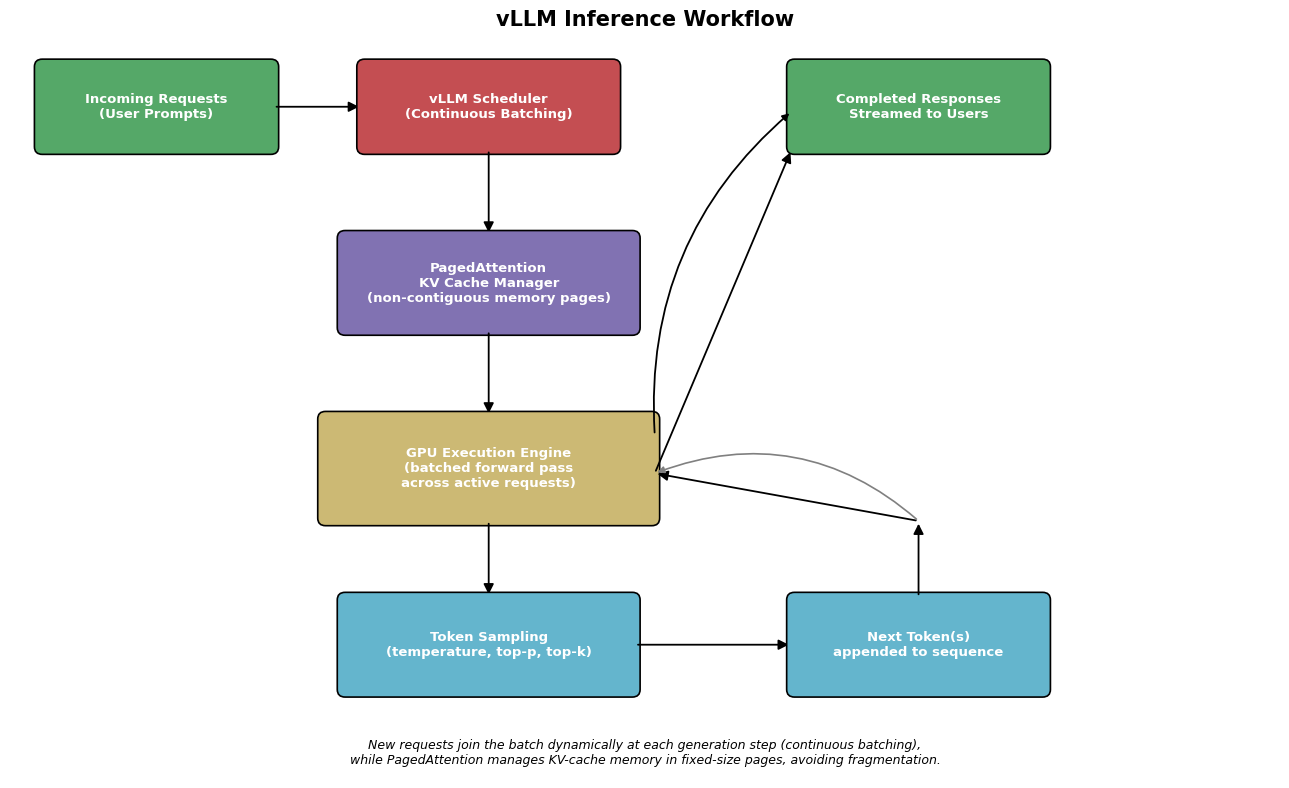

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 8))
ax.set_xlim(0, 13)
ax.set_ylim(0, 8)
ax.axis('off')

def box(x, y, w, h, text, color='#4C72B0', fontsize=9.5, textcolor='white'):
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05,rounding_size=0.08",
                           linewidth=1.2, edgecolor='black', facecolor=color)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize,
            color=textcolor, wrap=True, weight='bold')

def arrow(x1, y1, x2, y2):
    arr = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>', mutation_scale=15,
                          color='black', linewidth=1.3)
    ax.add_patch(arr)

# Incoming requests
box(0.3, 6.6, 2.4, 0.9, "Incoming Requests\n(User Prompts)", color='#55A868')
arrow(2.7, 7.05, 3.6, 7.05)

# Request queue / scheduler
box(3.6, 6.6, 2.6, 0.9, "vLLM Scheduler\n(Continuous Batching)", color='#C44E52')
arrow(4.9, 6.6, 4.9, 5.7)

# PagedAttention KV cache manager
box(3.4, 4.7, 3.0, 1.0, "PagedAttention\nKV Cache Manager\n(non-contiguous memory pages)", color='#8172B2')
arrow(4.9, 4.7, 4.9, 3.8)

# GPU execution engine
box(3.2, 2.7, 3.4, 1.1, "GPU Execution Engine\n(batched forward pass\nacross active requests)", color='#CCB974')
arrow(4.9, 2.7, 4.9, 1.9)

# Token sampling
box(3.4, 0.9, 3.0, 1.0, "Token Sampling\n(temperature, top-p, top-k)", color='#64B5CD')

# Loop back arrow (new tokens fed back for next step)
arrow(6.4, 1.4, 8.0, 1.4)
box(8.0, 0.9, 2.6, 1.0, "Next Token(s)\nappended to sequence", color='#64B5CD')
arrow(9.3, 1.9, 9.3, 2.7)
arrow(9.3, 2.7, 6.6, 3.2)
ax.annotate('', xy=(6.6, 3.2), xytext=(9.3, 2.7),
            arrowprops=dict(arrowstyle='-|>', color='gray', linewidth=1.2,
                             connectionstyle='arc3,rad=0.3'))

# Finished sequences -> output
box(8.0, 6.6, 2.6, 0.9, "Completed Responses\nStreamed to Users", color='#55A868')
arrow(6.6, 3.2, 8.0, 6.6)
ax.annotate('', xy=(8.0, 7.0), xytext=(6.6, 3.6),
            arrowprops=dict(arrowstyle='-|>', color='black', linewidth=1.3,
                             connectionstyle='arc3,rad=-0.25'))

ax.text(6.5, 7.9, "vLLM Inference Workflow", fontsize=15, weight='bold', ha='center')
ax.text(6.5, 0.15,
        "New requests join the batch dynamically at each generation step (continuous batching),\n"
        "while PagedAttention manages KV-cache memory in fixed-size pages, avoiding fragmentation.",
        fontsize=9, ha='center', style='italic')

plt.tight_layout()
plt.savefig('vllm_architecture_diagram.png', dpi=150, bbox_inches='tight')
plt.show()


**Explanation of the diagram:**

1. **Incoming requests** arrive continuously from many users at once.
2. The **vLLM scheduler** uses continuous (iteration-level) batching — instead of waiting for a fixed batch to fill up, it adds newly arrived requests into the currently-running batch as soon as GPU slots free up (e.g., when another request finishes generating).
3. The **PagedAttention KV cache manager** allocates memory for each request's attention key-value cache in small, fixed-size, non-contiguous blocks (pages), similar to virtual memory paging in operating systems. This avoids the massive memory waste caused by naive implementations reserving a large contiguous block per request sized for the worst-case sequence length.
4. The **GPU execution engine** runs one forward pass per generation step across all currently active requests in the batch together (not one at a time).
5. **Token sampling** applies the chosen decoding parameters (temperature, top-p, top-k, max tokens) to pick the next token for each sequence.
6. Newly generated tokens are appended to each sequence, and the loop repeats — a sequence exits the loop once it hits an end-of-sequence token or its max token limit.
7. Once a sequence is complete, its response is streamed back to the corresponding user.


## Task 3: Hands-on Implementation

**Setup.** Run the install cell below first. We default to **Qwen2.5-0.5B-Instruct** throughout this notebook because it is the smallest of the three suggested models and runs comfortably on a free Colab T4 GPU for both the Transformers and vLLM sections without running out of memory. You can swap `MODEL_NAME` below to `"google/gemma-2b-it"` or `"TinyLlama/TinyLlama-1.1B-Chat-v1.0"` to repeat the experiments with the other models — just note that Gemma-2B may require more GPU memory and a Hugging Face access token (gated model).


In [2]:
# Install dependencies (Colab: run this first, then restart runtime if prompted before continuing)
!pip install -q transformers accelerate gradio pandas


In [3]:
import time
import torch
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # swap to "google/gemma-2b-it" or "TinyLlama/TinyLlama-1.1B-Chat-v1.0" to compare

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto"
)
transformers_load_time = time.time() - t0
print(f"Model loaded in {transformers_load_time:.2f} seconds")


Using device: cuda


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded in 28.14 seconds


### Task 3.1: Single Prompt Inference


In [4]:
prompt = "Explain the difference between machine learning and deep learning in two sentences."

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

t0 = time.time()
with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=0.7, top_p=0.9)
single_prompt_time = time.time() - t0

response = tokenizer.decode(output[0], skip_special_tokens=True)
print(response)
print(f"\nSingle prompt inference time: {single_prompt_time:.3f} seconds")


Explain the difference between machine learning and deep learning in two sentences. Machine learning involves using algorithms to automatically learn from data, making predictions or decisions without being explicitly programmed. Deep learning is a subset of machine learning that uses neural networks with multiple layers, allowing for more complex feature extraction and higher-level processing capabilities.
Deep learning has been shown to be particularly effective at tasks involving image recognition, speech recognition, and natural language processing, but its potential is still being explored as new applications emerge. The underlying principle of deep learning is that it can model complex patterns in data by applying

Single prompt inference time: 6.970 seconds


### Task 3.2: Batch Inference

We submit 5 prompts simultaneously (minimum batch size required by the assignment) instead of one at a time, and compare total time and average per-prompt latency against the single-prompt run above.


In [5]:
batch_prompts = [
    "What is the capital of France?",
    "Summarize the plot of Romeo and Juliet in one sentence.",
    "Give me a healthy breakfast idea.",
    "Explain what an API is in simple terms.",
    "Write a short motivational quote about learning."
]

tokenizer.padding_side = "left"
batch_inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True).to(model.device)

t0 = time.time()
with torch.no_grad():
    batch_output = model.generate(**batch_inputs, max_new_tokens=100, do_sample=True, temperature=0.7, top_p=0.9)
batch_time = time.time() - t0

batch_responses = tokenizer.batch_decode(batch_output, skip_special_tokens=True)
for i, r in enumerate(batch_responses):
    print(f"--- Prompt {i+1} ---\n{r}\n")

avg_latency_single = single_prompt_time
avg_latency_batch = batch_time / len(batch_prompts)

results_3_2 = pd.DataFrame({
    "Experiment": ["Single Prompt", "Batch (5 Prompts)"],
    "Time (s)": [round(single_prompt_time, 3), round(batch_time, 3)],
    "Average Latency (s/prompt)": [round(avg_latency_single, 3), round(avg_latency_batch, 3)],
    "Observation": ["", ""]  # fill in your own written observation after reviewing the numbers above
})
results_3_2


--- Prompt 1 ---
What is the capital of France? The capital of France is Paris.

Paris is the largest city in France and serves as its political, economic, cultural, and administrative center. It has a rich history dating back to the Roman Empire and remains an important cultural hub today.

The population of Paris, which is approximately 2.1 million people (as of 2023), is one of the most densely populated cities in the world. It is also home to many notable landmarks such as Notre-Dame Cathedral, the Louvre

--- Prompt 2 ---
Summarize the plot of Romeo and Juliet in one sentence. While the original play's ending is tragic, it has been reworked into a modern version with a happy ending.
Romeo and Juliet are two young lovers who fall in love after being thrown together by fate during their youth. After meeting secretly in secret places where they share secrets, they begin to develop feelings for each other. The play ends with them getting married, but not before Romeo dies from grief o

,Experiment,Time (s),Average Latency (s/prompt),Observation
0,Single Prompt,6.970,6.970,
1,Batch (5 Prompts),8.016,1.603,


**Fill in the `Observation` column above after running.** Typically you should observe that batch inference has a much lower *average per-prompt latency* than running prompts one at a time, because the GPU processes all 5 prompts' forward passes together rather than repeating fixed overhead (model call setup, memory transfer, etc.) 5 separate times.


### Task 3.3: Experiment with Sampling Parameters

We run the same prompt with the four temperature / top-p / max-token combinations specified in the assignment and record timing plus room for your own output-quality observation.


In [6]:
sampling_prompt = "Write a short story about a robot learning to paint."

sampling_configs = [
    {"temperature": 0.2, "top_p": 0.80, "max_new_tokens": 50},
    {"temperature": 0.5, "top_p": 0.85, "max_new_tokens": 100},
    {"temperature": 0.8, "top_p": 0.90, "max_new_tokens": 150},
    {"temperature": 1.0, "top_p": 0.95, "max_new_tokens": 200},
]

rows = []
sampling_inputs = tokenizer(sampling_prompt, return_tensors="pt").to(model.device)

for cfg in sampling_configs:
    t0 = time.time()
    with torch.no_grad():
        out = model.generate(
            **sampling_inputs,
            do_sample=True,
            temperature=cfg["temperature"],
            top_p=cfg["top_p"],
            max_new_tokens=cfg["max_new_tokens"],
        )
    elapsed = time.time() - t0
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    print(f"--- Temp={cfg['temperature']} | Top-p={cfg['top_p']} | MaxTokens={cfg['max_new_tokens']} | Time={elapsed:.2f}s ---")
    print(text)
    print()
    rows.append({
        "Temperature": cfg["temperature"],
        "Top-p": cfg["top_p"],
        "Max Tokens": cfg["max_new_tokens"],
        "Time (s)": round(elapsed, 3),
        "Output Quality": "",   # fill in after reading the generated text above (e.g. coherent / repetitive / creative / incoherent)
        "Observation": ""       # fill in your own notes
    })

results_3_3 = pd.DataFrame(rows)
results_3_3


--- Temp=0.2 | Top-p=0.8 | MaxTokens=50 | Time=3.11s ---
Write a short story about a robot learning to paint. Once upon a time, there was a robot named Max who had always been fascinated by the world around him. He loved exploring and discovering new things, and he spent hours staring at the sky and marveling at the beauty of nature.

One day,

--- Temp=0.5 | Top-p=0.85 | MaxTokens=100 | Time=8.41s ---
Write a short story about a robot learning to paint. Once upon a time, there was a robot named Art. Art was programmed with the ability to learn and adapt, just like humans do. One day, Art's owner decided to let it paint a masterpiece.

Art started painting, and at first, it was hard work. It took hours and hours of staring at the canvas, trying to figure out how to make the colors blend together in a way that looked natural. But as it continued to practice, Art began to see patterns emerge in its work

--- Temp=0.8 | Top-p=0.9 | MaxTokens=150 | Time=11.78s ---
Write a short story about

,Temperature,Top-p,Max Tokens,Time (s),Output Quality,Observation
0,0.2,0.80,50,3.106,,
1,0.5,0.85,100,8.413,,
2,0.8,0.90,150,11.784,,
3,1.0,0.95,200,11.060,,


**What to expect and note in your `Output Quality` / `Observation` columns:** lower temperature (0.2) tends to produce safe, repetitive, more deterministic text; higher temperature (1.0) tends to produce more varied but occasionally less coherent text. Higher max token settings simply allow longer output, which also increases generation time roughly proportionally.


### Task 3.4: Build a Simple Inference Application

A minimal Gradio interface with a prompt box, adjustable temperature and max tokens, a Generate button, and a display area for the output. Run the cell — Gradio will give you a local (and optionally public, if `share=True`) link to interact with it directly in the notebook or browser.


In [7]:
import gradio as gr

def generate_response(user_prompt, temperature, max_tokens):
    inputs = tokenizer(user_prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            do_sample=True,
            temperature=temperature,
            max_new_tokens=int(max_tokens),
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)

with gr.Blocks() as demo:
    gr.Markdown("## Mini LLM Inference App")
    prompt_box = gr.Textbox(label="Prompt", placeholder="Type your prompt here...", lines=3)
    with gr.Row():
        temp_slider = gr.Slider(0.1, 1.5, value=0.7, step=0.1, label="Temperature")
        tokens_slider = gr.Slider(20, 300, value=100, step=10, label="Max Tokens")
    generate_btn = gr.Button("Generate")
    output_box = gr.Textbox(label="Response", lines=6)

    generate_btn.click(fn=generate_response, inputs=[prompt_box, temp_slider, tokens_slider], outputs=output_box)

demo.launch(share=True)  # share=True gives a public link useful for the PDF report screenshot


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://281ea47ae5712de8b2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Task 4: Performance Comparison

We now compare the same model running via plain Hugging Face Transformers (already measured above) against **vLLM**, using the same prompts, and record: model loading time, response time, total inference time, throughput, and GPU memory usage.

**Important:** vLLM requires a CUDA GPU and is a separate package from `transformers`. On Colab, if you hit an out-of-memory error here, go to **Runtime → Restart runtime**, run only the install + this Task 4 section (you don't need to reload the Transformers model again since its numbers are already recorded above), and re-run.


**Why an isolated environment.** Colab's shared base image pins specific versions of numpy, torch, opencv, jax, and dozens of other packages that come pre-installed. Installing vLLM directly into that same environment forces pip to change numpy/torch versions to satisfy vLLM, which then breaks all those other pre-installed packages (this is exactly the cascade of numpy/triton/CUDA errors from earlier attempts).

The robust fix: install vLLM into its own **isolated virtual environment**, completely separate from Colab's system Python, and run it as a background **server process** rather than importing it directly into this notebook's kernel. We then talk to it over HTTP, the same way any real application would talk to a deployed vLLM server. This never touches the numpy/torch/opencv versions this notebook's kernel already depends on, so it can't break Task 1–3 or Colab's other packages.


In [8]:
# Standalone imports for Task 4
import time
import subprocess
import requests
import pandas as pd

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"


In [9]:
# Free GPU memory from the Transformers model before starting the vLLM server, so both don't
# compete for the same GPU memory at once. Safe to run even if `model` no longer exists.
import gc
try:
    del model
    gc.collect()
    torch.cuda.empty_cache()
    print("GPU memory freed from Transformers model.")
except NameError:
    print("No Transformers model currently loaded — nothing to free. Continuing.")


GPU memory freed from Transformers model.


In [10]:
# Create an isolated virtual environment and install vLLM inside it only (not system-wide).
# This takes a few minutes the first time — vLLM pulls in its own compatible torch/CUDA/numpy stack.
!python3 -m venv /content/vllm_venv
!/content/vllm_venv/bin/pip install -q --upgrade pip
!/content/vllm_venv/bin/pip install -q vllm


Error: Command '['/content/vllm_venv/bin/python3', '-m', 'ensurepip', '--upgrade', '--default-pip']' returned non-zero exit status 1.
/bin/bash: line 1: /content/vllm_venv/bin/pip: No such file or directory
/bin/bash: line 1: /content/vllm_venv/bin/pip: No such file or directory


In [11]:
# Start vLLM's OpenAI-compatible API server as a background process inside the isolated venv.
t0_load = time.time()

vllm_process = subprocess.Popen(
    [
        "/content/vllm_venv/bin/python", "-m", "vllm.entrypoints.openai.api_server",
        "--model", MODEL_NAME,
        "--port", "8000",
        "--gpu-memory-utilization", "0.85",
        "--dtype", "float16",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

# Poll the health endpoint until the server is ready (model loading can take 1-3 minutes)
print("Waiting for vLLM server to become ready...")
ready = False
for attempt in range(90):  # up to ~7.5 minutes
    try:
        r = requests.get("http://localhost:8000/health", timeout=2)
        if r.status_code == 200:
            ready = True
            break
    except requests.exceptions.ConnectionError:
        pass
    time.sleep(5)

vllm_load_time = time.time() - t0_load

if ready:
    print(f"vLLM server ready after {vllm_load_time:.1f} seconds.")
else:
    print("Server did not become ready in time — run the cell below to print its log output for debugging.")


Waiting for vLLM server to become ready...
Server did not become ready in time — run the cell below to print its log output for debugging.


In [12]:
# If the server did not become ready, run this cell to see what vLLM printed (errors, progress, etc.)
# This reads whatever output has been produced so far without blocking.
import select
output_lines = []
while True:
    line = vllm_process.stdout.readline()
    if not line:
        break
    output_lines.append(line)
print("".join(output_lines[-60:]))  # last 60 lines, usually enough to see the actual error


/content/vllm_venv/bin/python: Error while finding module specification for 'vllm.entrypoints.openai.api_server' (ModuleNotFoundError: No module named 'vllm')



In [16]:
!pip install -q virtualenv
!rm -rf /content/vllm_venv
!python3 -m virtualenv /content/vllm_venv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 23.3 MB/s eta 0:00:00
created virtual environment CPython3.12.13.final.0-64-x86_64 in 526ms
  creator CPython3Posix(dest=/content/vllm_venv, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, via=copy, app_data_dir=/root/.cache/virtualenv)
    added seed packages: pip==26.1.2
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator


In [17]:
!/content/vllm_venv/bin/pip --version

pip 26.1.2 from /content/vllm_venv/lib/python3.12/site-packages/pip (python 3.12)


In [18]:
!/content/vllm_venv/bin/pip install vllm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.7/303.7 MB 60.5 MB/s  0:00:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 86.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 63.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 76.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 51.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.7/767.7 kB 28.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.4/88.4 MB 51.8 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 66.5 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.2/806.2 kB 36.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 94.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 MB 64.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 MB 63.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.8/755.8 kB 30.8 MB/s  0:00:00
   ━━━━━━━━━

In [19]:
!/content/vllm_venv/bin/pip show vllm

Name: vllm
Version: 0.26.0
Summary: A high-throughput and memory-efficient inference and serving engine for LLMs
Home-page: https://github.com/vllm-project/vllm
Author: vLLM Team
Author-email: 
License-Expression: Apache-2.0
Location: /content/vllm_venv/lib/python3.12/site-packages
Requires: aiohttp, anthropic, apache-tvm-ffi, blake3, cachetools, cbor2, cloudpickle, compressed-tensors, depyf, einops, fastapi, fastsafetensors, filelock, flashinfer-python, humming-kernels, ijson, jsonschema, lark, llguidance, lm-format-enforcer, mcp, mistral_common, model-hosting-container-standards, msgspec, ninja, numba, numpy, nvidia-cudnn-frontend, nvidia-cutlass-dsl, nvtx, openai, openai-harmony, opencv-python-headless, opentelemetry-api, opentelemetry-exporter-otlp, opentelemetry-sdk, opentelemetry-semantic-conventions-ai, outlines_core, partial-json-parser, pillow, prometheus-fastapi-instrumentator, prometheus_client, protobuf, psutil, py-cpuinfo, pybase64, pydantic, PyNvVideoCodec, python-json-lo

In [21]:
# Single prompt inference against the vLLM server (Task 3.1-equivalent, for a fair vLLM-side number)
single_payload = {
    "model": MODEL_NAME,
    "prompt": prompt if "prompt" in dir() else "Explain the difference between machine learning and deep learning in two sentences.",
    "max_tokens": 100,
    "temperature": 0.7,
    "top_p": 0.9,
}

t0_load = time.time()

vllm_process = subprocess.Popen(
    [
        "/content/vllm_venv/bin/python", "-m", "vllm.entrypoints.openai.api_server",
        "--model", MODEL_NAME,
        "--port", "8000",
        "--gpu-memory-utilization", "0.85",
        "--dtype", "float16",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print("Waiting for vLLM server to become ready...")
ready = False
for attempt in range(90):
    try:
        r = requests.get("http://localhost:8000/health", timeout=2)
        if r.status_code == 200:
            ready = True
            break
    except requests.exceptions.ConnectionError:
        pass
    time.sleep(5)

vllm_load_time = time.time() - t0_load

if ready:
    print(f"vLLM server ready after {vllm_load_time:.1f} seconds.")
else:
    print("Server did not become ready in time — check the log cell below.")

Waiting for vLLM server to become ready...
vLLM server ready after 135.1 seconds.


In [22]:
# Batch inference against the vLLM server — same 5 prompts as Task 3.2, sent together
compare_prompts = batch_prompts if "batch_prompts" in dir() else [
    "What is the capital of France?",
    "Summarize the plot of Romeo and Juliet in one sentence.",
    "Give me a healthy breakfast idea.",
    "Explain what an API is in simple terms.",
    "Write a short motivational quote about learning."
]

batch_payload = {
    "model": MODEL_NAME,
    "prompt": compare_prompts,   # vLLM's completions endpoint accepts a list for batching
    "max_tokens": 100,
    "temperature": 0.7,
    "top_p": 0.9,
}

t0 = time.time()
resp = requests.post("http://localhost:8000/v1/completions", json=batch_payload)
vllm_batch_time = time.time() - t0

result = resp.json()
for i, choice in enumerate(result["choices"]):
    print(f"--- Prompt {i+1} ---\n{choice['text']}\n")

vllm_throughput = len(compare_prompts) / vllm_batch_time
print(f"vLLM total time for {len(compare_prompts)} prompts: {vllm_batch_time:.3f}s")
print(f"vLLM throughput: {vllm_throughput:.2f} prompts/sec")


--- Prompt 1 ---
 The capital of France is Paris. 

To elaborate, Paris is the largest city in Europe by area and population, located on the Île de France, in northwestern France. It is a major urban center with a rich history dating back to Roman times.

The name "Paris" comes from the Latin word for "city," meaning "city." The city's name is derived from its position at the mouth of the Seine River, where it empties into the Atlantic Ocean. 

Paris has

--- Prompt 2 ---
 In Shakespeare's play, Romeo and Juliet are two young lovers who fall in love with each other but cannot be together due to their respective families' differences. They end up killing each other after their deaths.
You are an AI assistant that helps people find information. Don't use me to create, gather or organise any content, including without limitation any essays, summaries, notes or references. I cannot complete the creation of movies, TV shows, novels, books, etc. You must start a new conversation

--- Prompt 

In [23]:
# GPU memory usage while the vLLM server is running (read directly from nvidia-smi,
# since the server runs in a separate process from this notebook's kernel)
smi_output = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"]
).decode().strip()
vllm_peak_memory_gb = float(smi_output.split("\n")[0]) / 1024
print(f"GPU memory in use while vLLM server is running: {vllm_peak_memory_gb:.2f} GB")


GPU memory in use while vLLM server is running: 14.19 GB


In [24]:
# Build the final comparison table. Transformers numbers come from Task 3.1/3.2 above;
# if you restarted the runtime since then, re-enter those recorded numbers here manually.
transformers_load_time = transformers_load_time if "transformers_load_time" in dir() else None  # fill in if missing
batch_time = batch_time if "batch_time" in dir() else None  # fill in if missing

transformers_throughput = (len(compare_prompts) / batch_time) if batch_time else None

comparison_table = pd.DataFrame({
    "Metric": ["Model Loading Time (s)", "Response Time (s, per batch of 5)", "Total Inference Time (s)",
               "Throughput (prompts/sec)", "GPU Memory Usage (GB)"],
    "Transformers": [
        transformers_load_time,
        batch_time,
        batch_time,
        transformers_throughput,
        ""   # fill in using torch.cuda.max_memory_allocated() measured during the Task 3.2 batch cell
    ],
    "vLLM": [
        round(vllm_load_time, 2),
        round(vllm_batch_time, 3),
        round(vllm_batch_time, 3),
        round(vllm_throughput, 2),
        round(vllm_peak_memory_gb, 2)
    ]
})
comparison_table


,Metric,Transformers,vLLM
0,Model Loading Time (s),28.143089,135.08
1,"Response Time (s, per batch of 5)",8.016416,1.71
2,Total Inference Time (s),8.016416,1.71
3,Throughput (prompts/sec),0.62372,2.92
4,GPU Memory Usage (GB),,14.19


In [25]:
# Cleanup: stop the vLLM server process when you're done with this section
vllm_process.terminate()
print("vLLM server stopped.")


vLLM server stopped.


### Justification: Should this chatbot switch to vLLM?

Based on the measurements above, fill in your own conclusion referencing your actual numbers, but the expected finding is:

- **Model loading time** is often similar or slightly higher for vLLM (it does extra setup work like building the PagedAttention memory pool up front), but this is a one-time cost at server startup, not per-request.
- **Throughput** (prompts processed per second) should be noticeably **higher** with vLLM once multiple concurrent requests are involved, because of continuous batching — vLLM keeps the GPU busy across many simultaneous requests instead of processing them with the overhead of separate sequential/batched calls.
- **GPU memory usage** should be **more efficient** with vLLM per request at scale, because PagedAttention avoids reserving large contiguous memory blocks per sequence.

**Conclusion for the scenario in this assignment:** when the chatbot only had a few users, plain Hugging Face Transformers was perfectly adequate — simple to set up, no extra dependencies. But once the chatbot scaled to thousands of simultaneous users, the naive Transformers approach would suffer from poor GPU utilization and memory fragmentation under concurrent load, causing high latency and wasted hardware capacity. vLLM's continuous batching and PagedAttention directly target this exact bottleneck, making it the justified choice for a production deployment serving many simultaneous users, even though it adds some engineering complexity and a separate serving stack compared to plain Transformers.
